In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import MSTL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from time import time
import seaborn as sns
sns.set_style("darkgrid")
plt.rc("figure", figsize=(16, 12))

https://www.statsmodels.org/dev/examples/notebooks/generated/mstl_decomposition.html

In [8]:
# Load datasets from project root (notebook in src/)
from pathlib import Path
root = Path.cwd().resolve().parents[0]  # project root when running from src/

train_path = root / 'data' / 'NSW' / 'train.csv'
validation_path = root / 'data' / 'NSW' / 'validation.csv'
test_path = root / 'data' / 'NSW' / 'test.csv'


train = pd.read_csv(train_path, parse_dates=['DATETIME'], index_col='DATETIME')
validation = pd.read_csv(validation_path, parse_dates=['DATETIME'], index_col='DATETIME')
test = pd.read_csv(test_path, parse_dates=['DATETIME'], index_col='DATETIME')

# Quick check
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (112651, 7)
Validation shape: (37550, 7)
Test shape: (37552, 55)


,TOTALDEMAND,demand_1_day_ago,demand_1_week_ago,demand_1_year_ago,TEMPERATURE,RMSE_48,TSE_48
DATETIME,,,,,,,
2010-07-02 12:00:00,11409.84,10035.63,9766.12,8038.00,11.0,637.616980,1.951466e+07
2010-07-02 12:30:00,11276.77,9686.17,9521.15,7809.31,11.5,706.576978,2.396405e+07
2010-07-02 13:00:00,11208.75,9513.42,9318.45,7483.69,11.6,784.498292,2.954100e+07
2010-07-02 13:30:00,11184.47,9255.59,9108.57,7117.23,11.8,862.789475,3.573147e+07
2010-07-02 14:00:00,11141.20,9019.79,8863.47,6812.03,12.0,927.314578,4.127579e+07


In [9]:
train.index.freq = '30min'
validation.index.freq = '30min'
test.index.freq = '30min'

In [10]:
train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 112651 entries, 2010-07-02 12:00:00 to 2016-12-04 09:00:00
Freq: 30min
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   TOTALDEMAND        112651 non-null  float64
 1   demand_1_day_ago   112651 non-null  float64
 2   demand_1_week_ago  112651 non-null  float64
 3   demand_1_year_ago  112651 non-null  float64
 4   TEMPERATURE        112651 non-null  float64
 5   RMSE_48            112651 non-null  float64
 6   TSE_48             112651 non-null  float64
dtypes: float64(7)
memory usage: 6.9 MB


<Figure size 1600x1200 with 0 Axes>

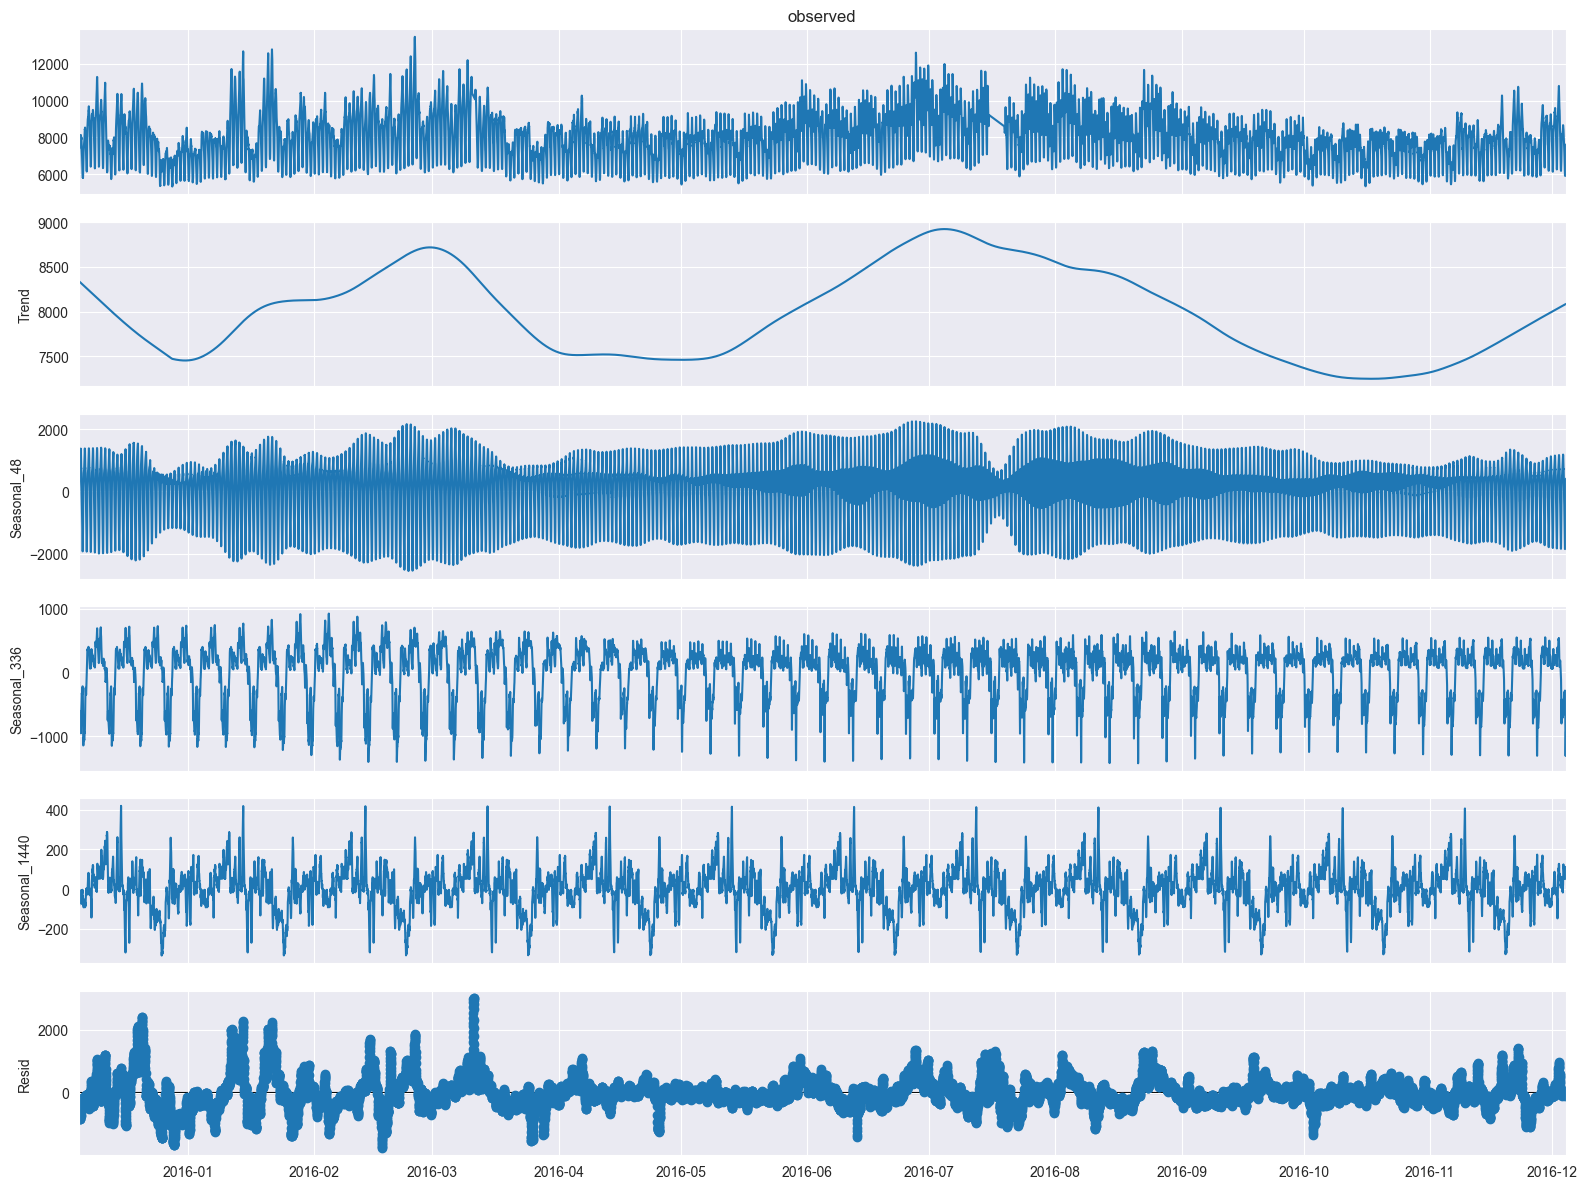

In [45]:
lookback_window = 17532
subset_train = train[train.index.max() - pd.Timedelta(hours=lookback_window/2):]


stl = MSTL(
    subset_train['TOTALDEMAND'], 
    windows=(11, 15, 19*4-1),
    periods=(48, 336, 48*30),
    iterate=3,
    stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
res = stl.fit()
plt.figure(figsize=(16,12))
fig = res.plot()
plt.show()

In [40]:
res.trend

DATETIME
2015-12-05 03:00:00    8251.485401
2015-12-05 03:30:00    8250.716924
2015-12-05 04:00:00    8249.948485
2015-12-05 04:30:00    8249.180084
2015-12-05 05:00:00    8248.411721
                          ...     
2016-12-04 07:00:00    8022.792250
2016-12-04 07:30:00    8023.247944
2016-12-04 08:00:00    8023.703622
2016-12-04 08:30:00    8024.159282
2016-12-04 09:00:00    8024.614925
Freq: 30min, Name: trend, Length: 17533, dtype: float64

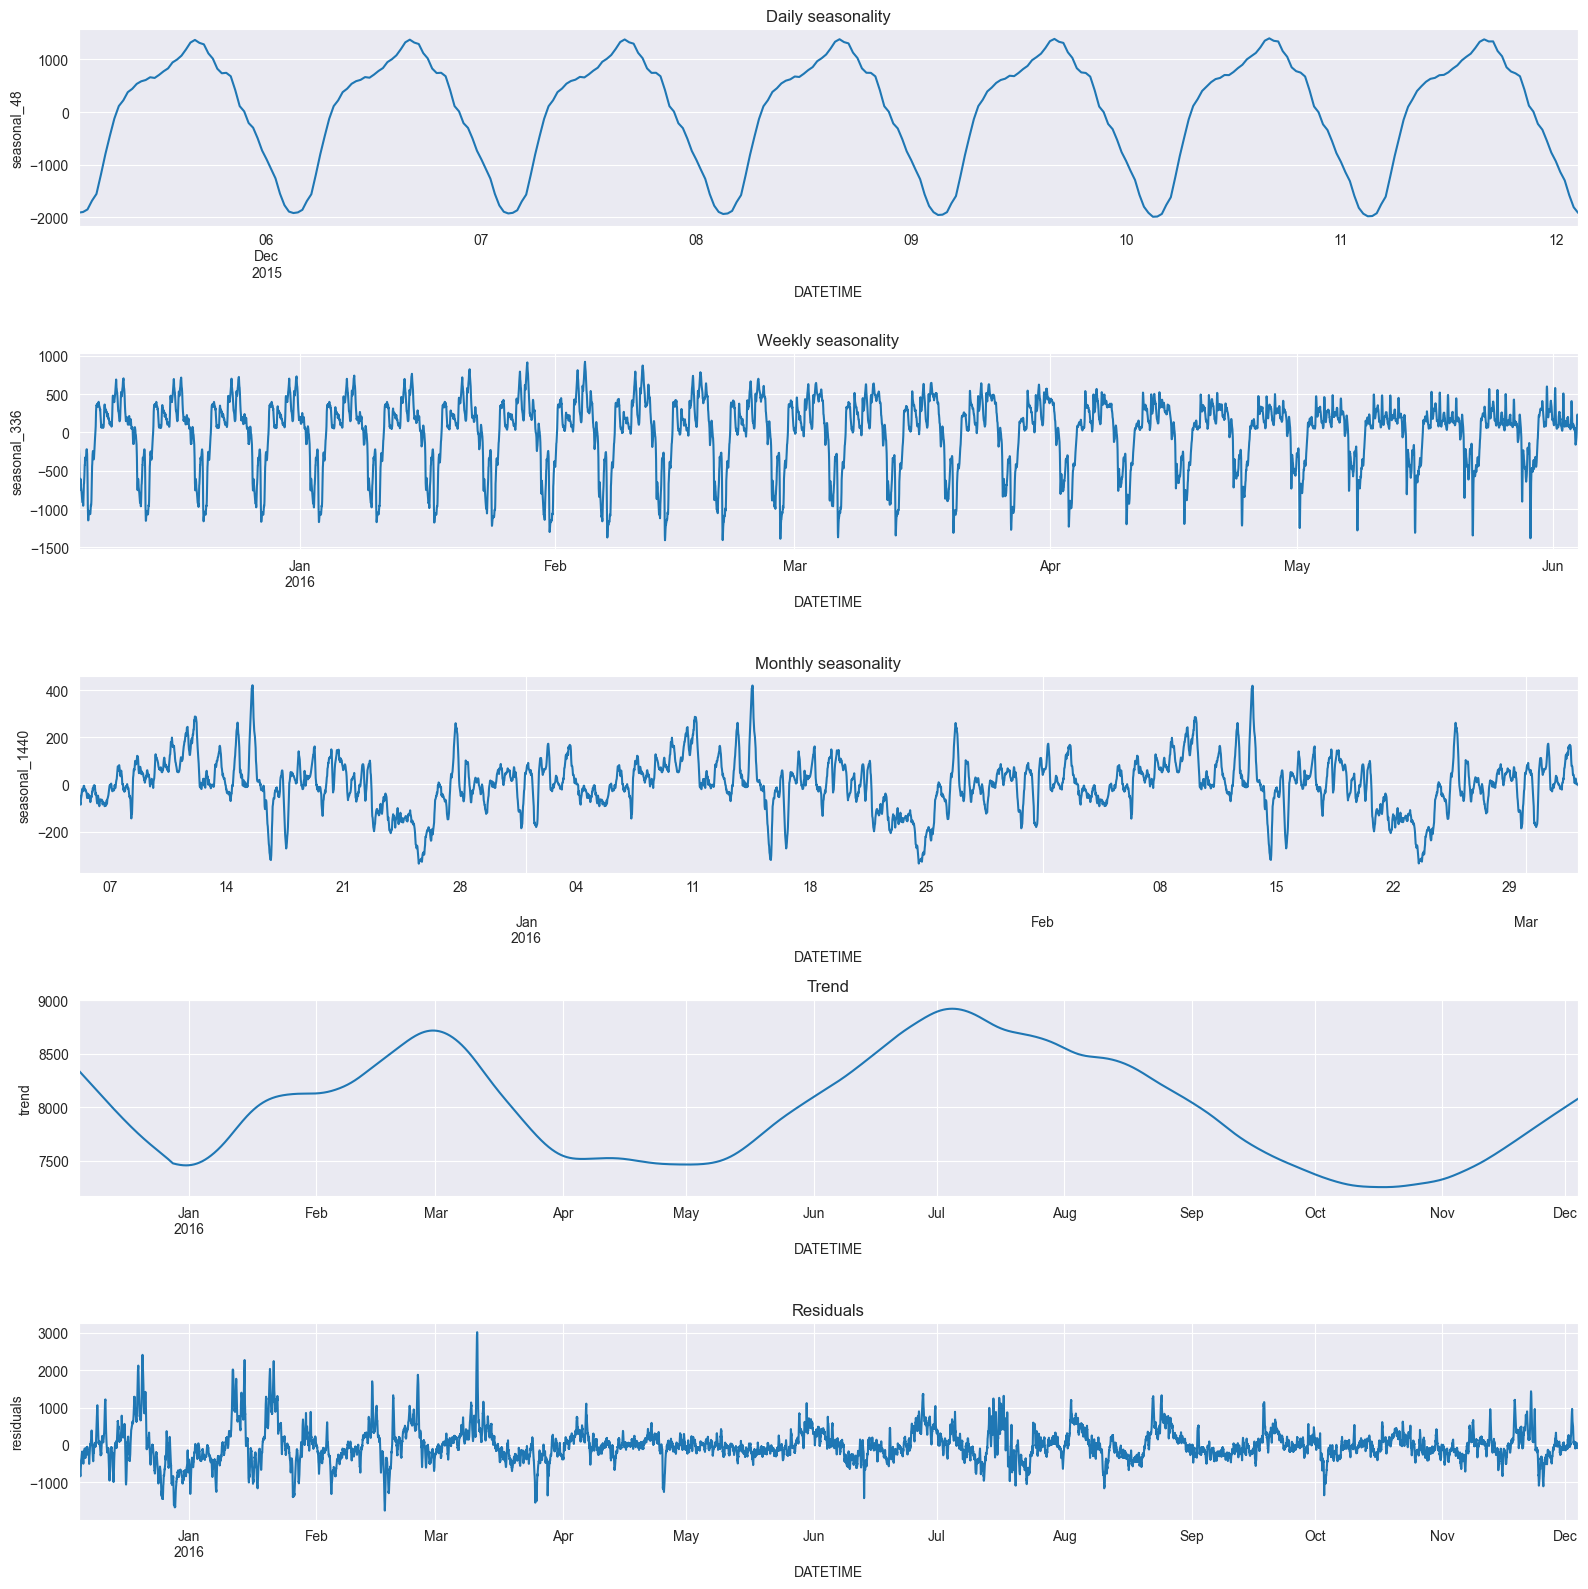

In [48]:
fig, ax = plt.subplots(nrows=5, figsize=[16, 16])
res.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_48")
ax[0].set_title("Daily seasonality")

res.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
ax[1].set_ylabel("seasonal_336")
ax[1].set_title("Weekly seasonality")

res.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
ax[2].set_ylabel("seasonal_1440")
ax[2].set_title("Monthly seasonality")

res.trend.iloc[: 48 * 365].plot(ax=ax[3])
ax[3].set_ylabel("trend")
ax[3].set_title("Trend")

res.resid.iloc[: 48 * 365].plot(ax=ax[4])
ax[4].set_ylabel("residuals")
ax[4].set_title("Residuals")

plt.tight_layout()

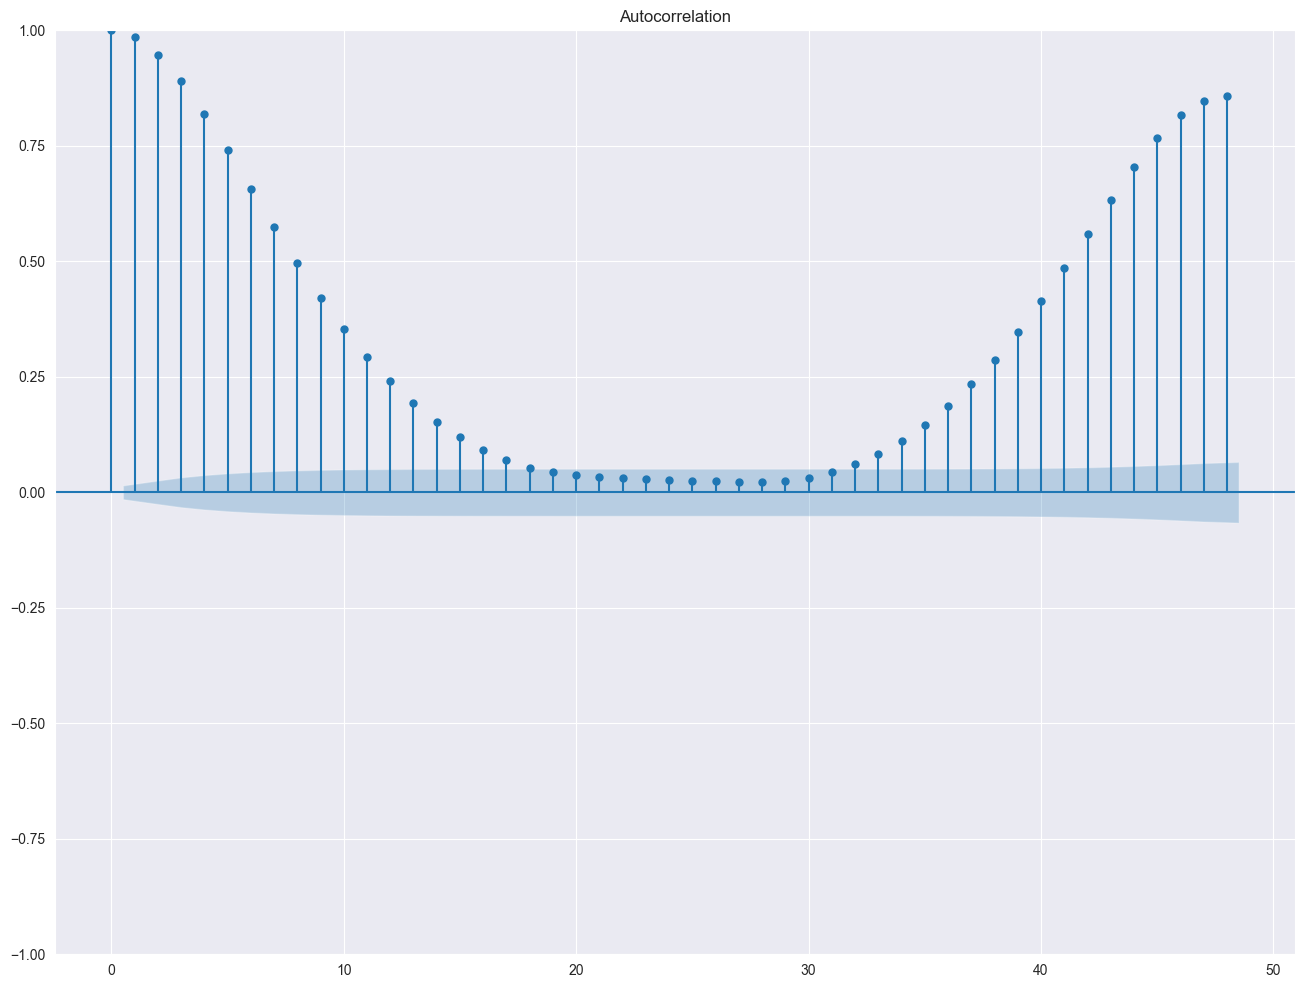

In [ ]:
acf_plot = plot_acf(subset_train['TOTALDEMAND'], lags=min(48, len(subset_train)/2-1))

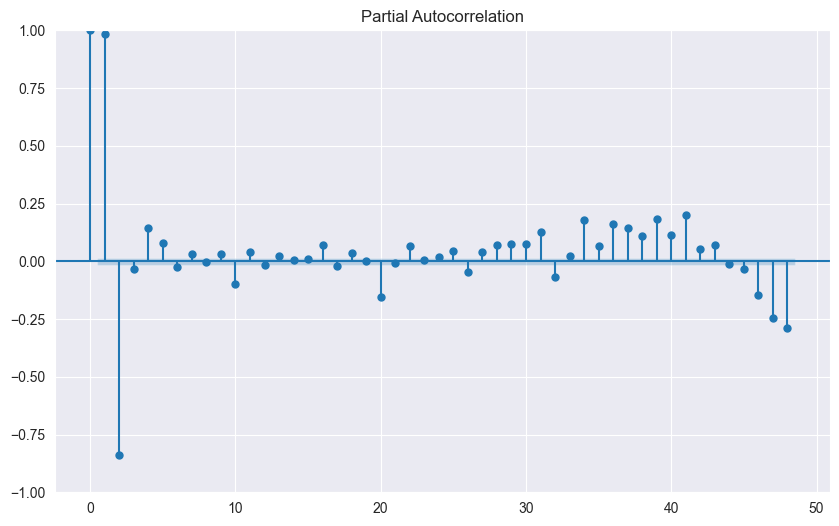

In [121]:
pacf_plot = plot_pacf(subset_train['TOTALDEMAND'], lags=min(48, len(subset_train)/2-1))

https://otexts.com/fpp3/

The data is not stationary because of obvious seasonality trends. The ACF also supports this fact that it slowly decreases and increases again.

In [101]:
plt.rc("figure", figsize=(10, 6))

In [95]:
diff_48 = subset_train['TOTALDEMAND'].diff(48).dropna()
stl_48 = MSTL(
    diff_48, 
    windows=(11, 15, 19*4-1),
    periods=(48, 336, 48*30),
    iterate=3,
    stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
res_48 = stl_48.fit()

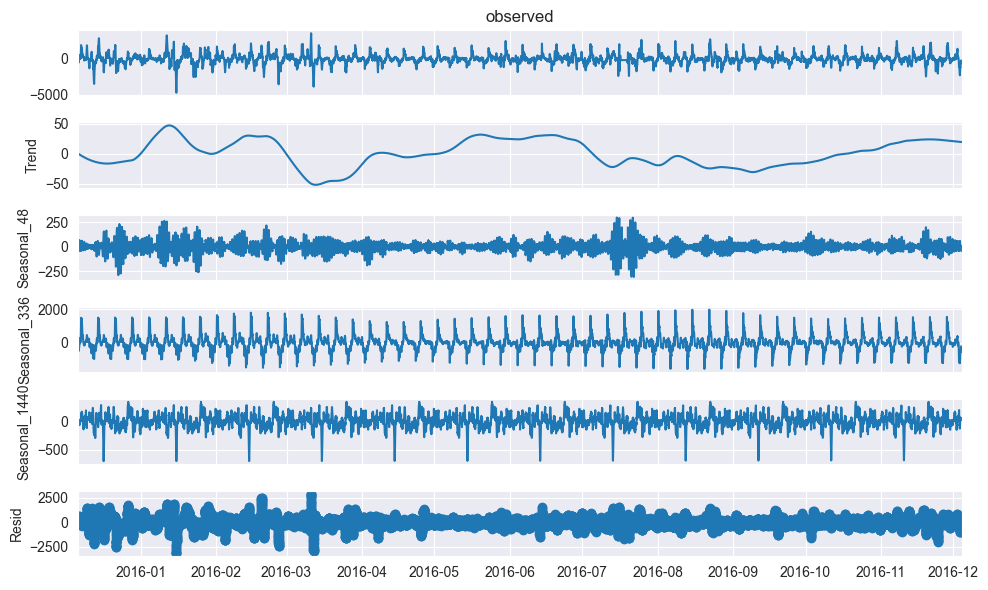

C:\Users\kyim1\AppData\Local\Temp\ipykernel_9168\3796533937.py:27: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


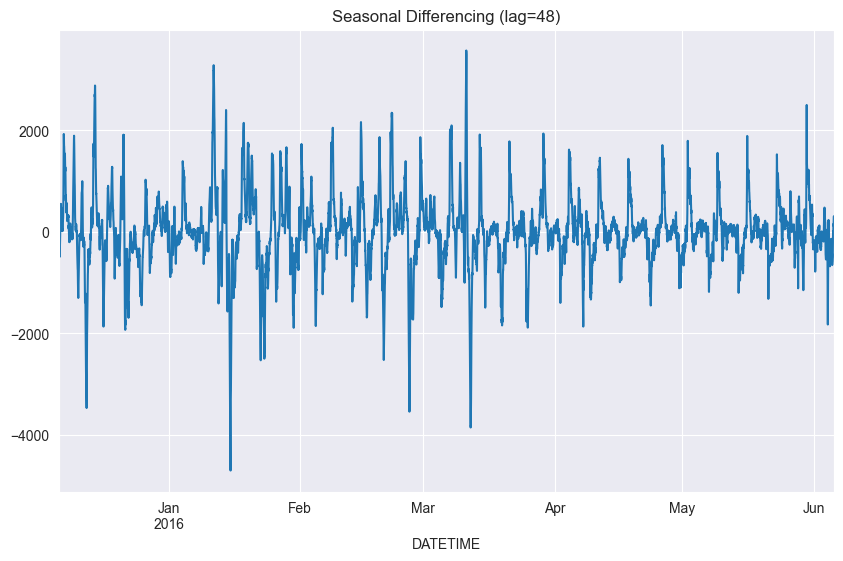

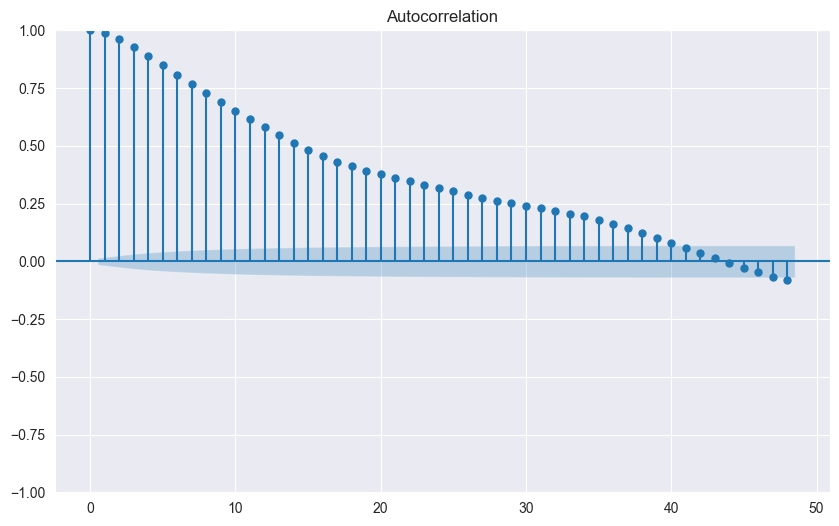

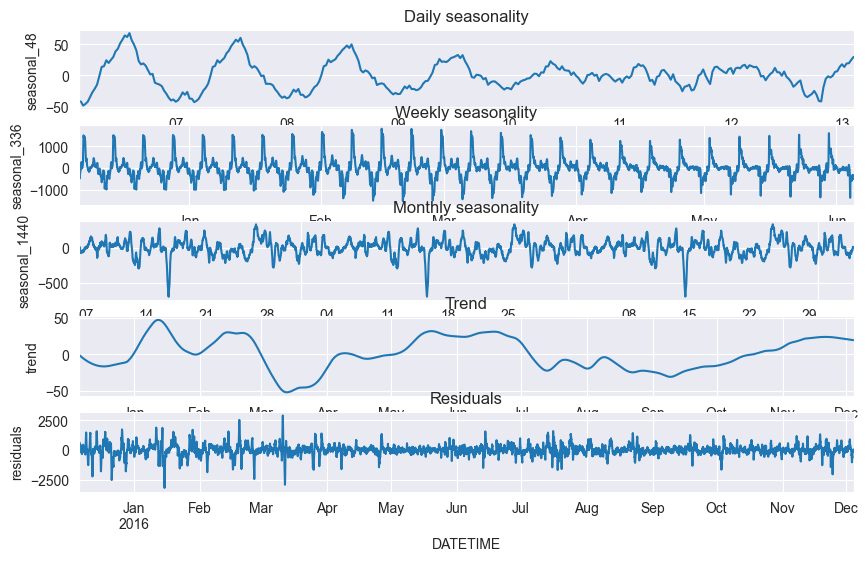

In [96]:
fig = res_48.plot()
plt.show()
diff_48.iloc[:lookback_window//2].plot(title='Seasonal Differencing (lag=48)')
pacf_plot_diff_48 = plot_acf(diff_48, lags=min(48, len(diff_48)/2-1))

fig, ax = plt.subplots(nrows=5)
res_48.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_48")
ax[0].set_title("Daily seasonality")

res_48.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
ax[1].set_ylabel("seasonal_336")
ax[1].set_title("Weekly seasonality")

res_48.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
ax[2].set_ylabel("seasonal_1440")
ax[2].set_title("Monthly seasonality")

res_48.trend.iloc[: 48 * 365].plot(ax=ax[3])
ax[3].set_ylabel("trend")
ax[3].set_title("Trend")

res_48.resid.iloc[: 48 * 365].plot(ax=ax[4])
ax[4].set_ylabel("residuals")
ax[4].set_title("Residuals")

plt.tight_layout()

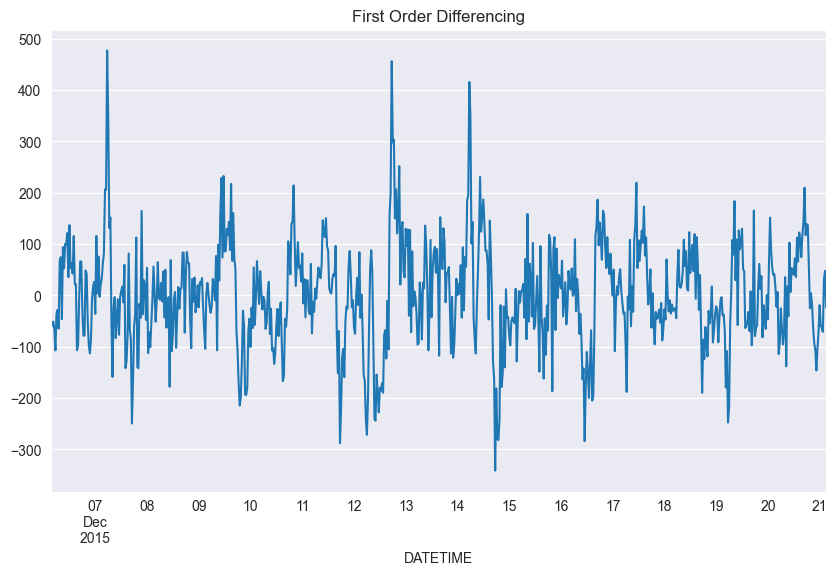

In [ ]:
# Create differenced series
diff_1 = diff_48.diff().dropna()
diff_1.iloc[:720].plot(title='First Order Differencing')
stl_1 = MSTL(
    diff_1, 
    windows=(11, 15, 19*4-1),
    periods=(48, 336, 48*30),
    iterate=3,
    stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
res_1 = stl_1.fit()

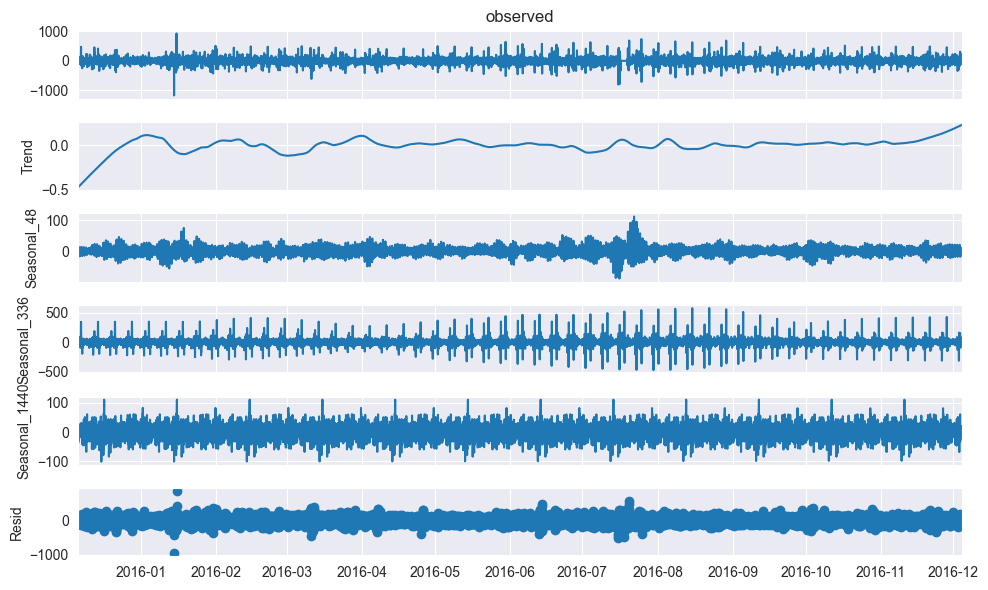

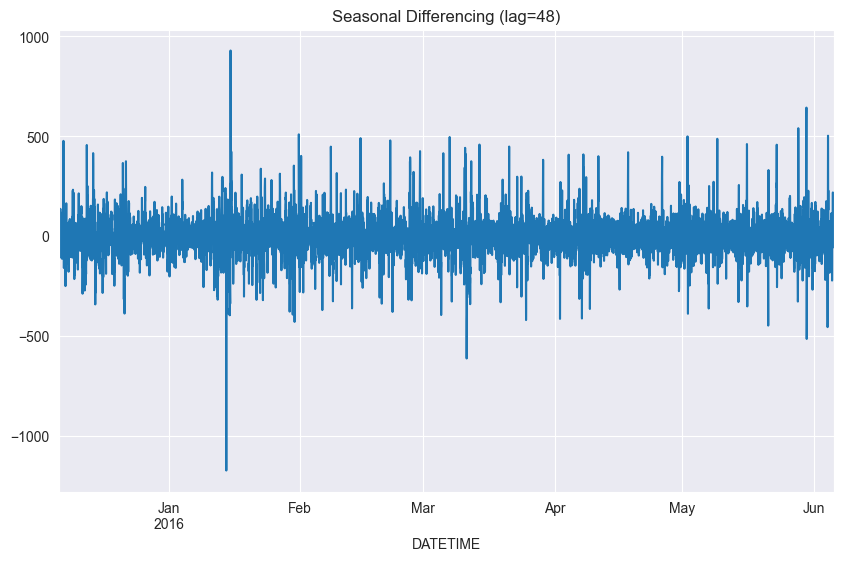

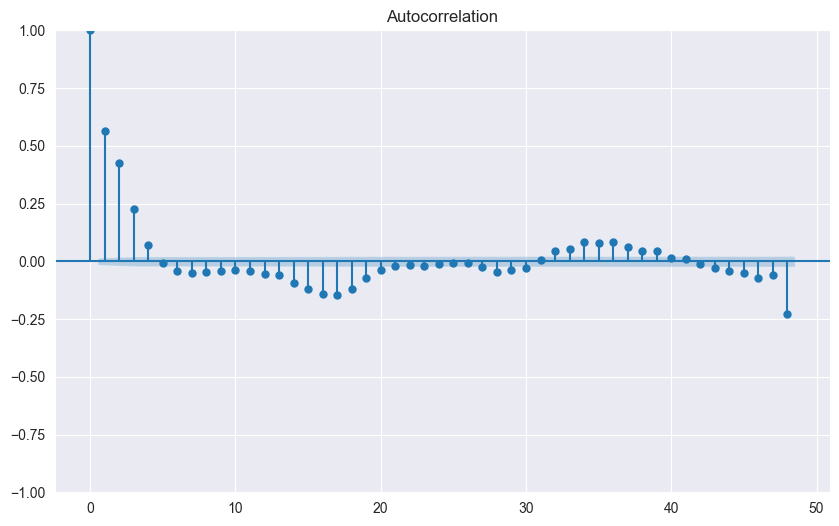

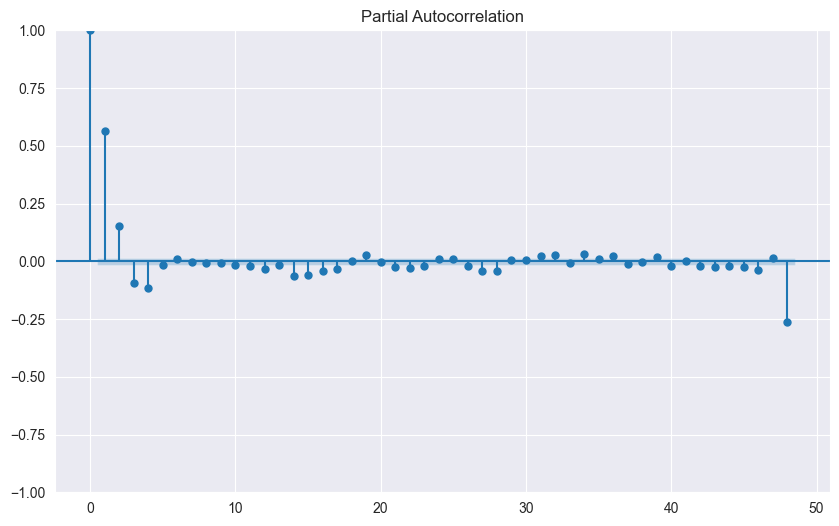

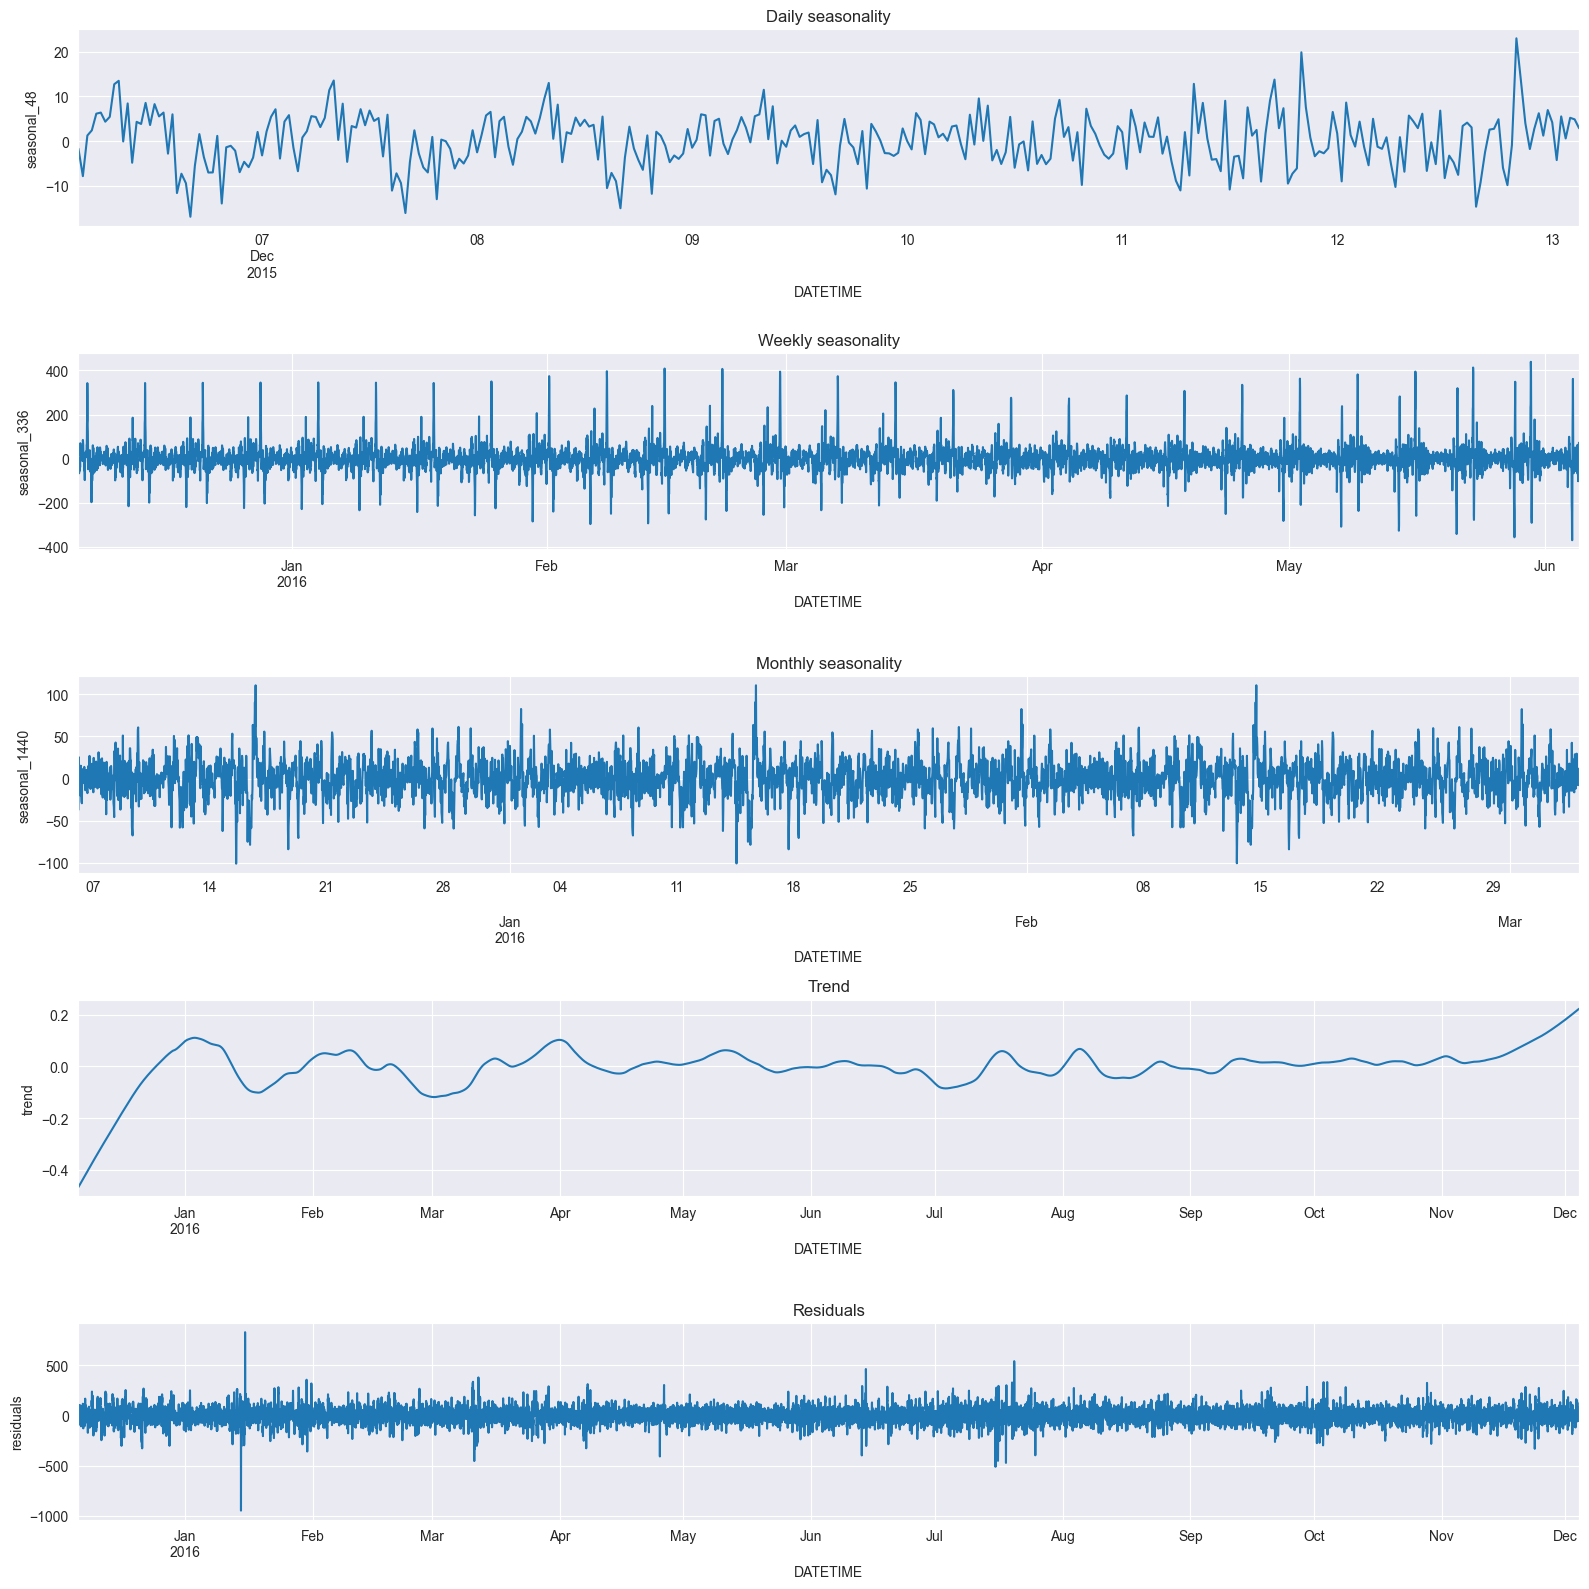

In [122]:
fig = res_1.plot()
plt.show()
diff_1.iloc[:lookback_window//2].plot(title='Seasonal Differencing (lag=48)')
acf_plot_diff_1 = plot_acf(diff_1, lags=min(48, len(diff_1)/2-1))
pacf_plot_diff_1 = plot_pacf(diff_1, lags=min(48, len(diff_1)/2-1))
fig, ax = plt.subplots(nrows=5, figsize=[16, 16])
res_1.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_48")
ax[0].set_title("Daily seasonality")

res_1.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
ax[1].set_ylabel("seasonal_336")
ax[1].set_title("Weekly seasonality")

res_1.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
ax[2].set_ylabel("seasonal_1440")
ax[2].set_title("Monthly seasonality")

res_1.trend.iloc[: 48 * 365].plot(ax=ax[3])
ax[3].set_ylabel("trend")
ax[3].set_title("Trend")

res_1.resid.iloc[: 48 * 365].plot(ax=ax[4])
ax[4].set_ylabel("residuals")
ax[4].set_title("Residuals")

plt.tight_layout()

In [125]:
lookback_window = 17532 / 4
subset_train = train[train.index.max() - pd.Timedelta(hours=lookback_window):]

In [ ]:
p = 3
d = 1
q = 0
p_s = 1
d_s = 1
q_s = 4
period = 48

model_sarima = SARIMAX(
    subset_train['TOTALDEMAND'], 
    order=(p,d,q), 
    seasonal_order=(p_s,d_s,q_s,period)
    )
start = time()
model_fit_sarima = model_sarima.fit()
end = time()
print(f"SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) Model fitting took {end - start:.2f} seconds")
print(model_fit_sarima.summary())

2016-12-04 09:30:00 2016-12-11 09:30:00


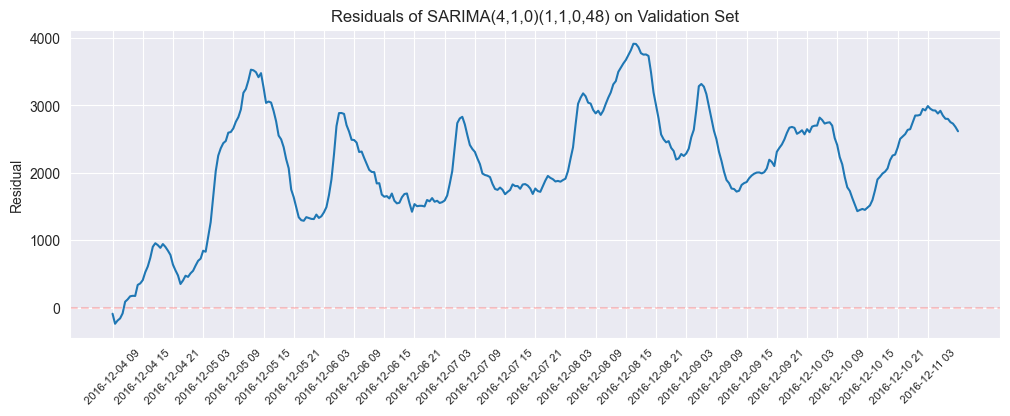

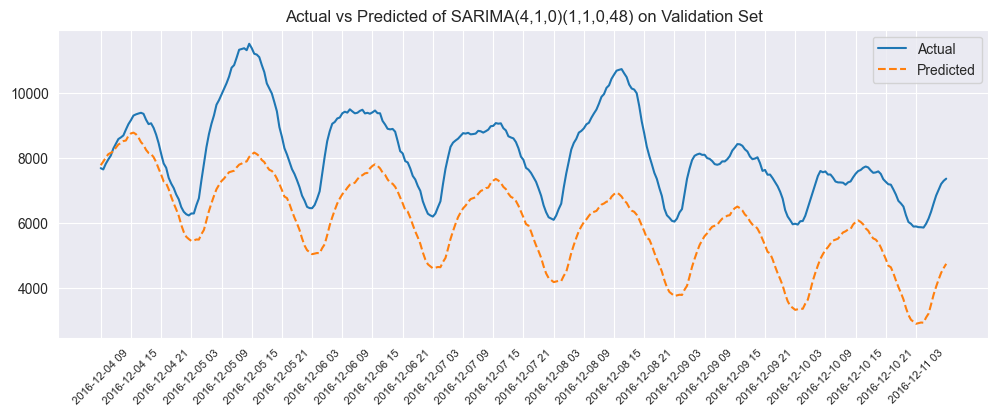

In [ ]:
from datetime import datetime, timedelta
horizon = 336
validation_target = validation['TOTALDEMAND'].iloc[:horizon+1]
print(validation_target.index.min(), validation_target.index.max())
predictions = model_fit_sarima.predict(start=validation_target.index[0], end=validation_target.index[-1])
residuals = validation_target - predictions

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title(f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.ylabel('Residual')
# for xticks, show as format 'YYYY-MM-DD HH'
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.axhline(0, color='red', linestyle='--', alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(validation_target, label='Actual')
plt.plot(predictions, label='Predicted', linestyle='--')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.title(f'Actual vs Predicted of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.legend()
plt.show()

Python has an excellent library for exactly this called pmdarima (Pyramid ARIMA). It functions very similarly to R's highly popular auto.arima() function.

It automatically discovers the optimal order for an ARIMA or SARIMA model by searching through combinations of p, d, q (and seasonal P, D, Q) and selecting the model with the lowest AIC or BIC score.

You can install it via pip:

pip install pmdarima

```python
import pmdarima as pm

# Auto-fit the SARIMA model
# Note: Since your data is 30-min intervals, your seasonal period (m) is 48 for daily seasonality.
auto_model = pm.auto_arima(
    subset_train['TOTALDEMAND'],
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    m=48,              # Seasonal period (48 for daily seasonality with 30-min data)
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None,            # Let the model determine 'd'
    D=None,            # Let the model determine 'D'
    seasonal=True,     # Enable SARIMA
    trace=True,        # Print the search progress
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True      # Use stepwise algorithm to search faster (rather than full grid search)
)

print(auto_model.summary())
```
A Quick Warning for Your Data
Because your data frequency is high (30-minute intervals implies m=48 for daily or m=336 for weekly), fitting auto_arima can be extremely computationally expensive and slow.

If you use it, I highly recommend:

Ensuring stepwise=True is set (it uses a smart search algorithm instead of checking every single combination).
Potentially testing it on a much smaller subset_train slice first to get a baseline idea of the optimal parameters before running it on a larger dataset.